# Silicon Results for q-Independent ISDF

Ensure the database of results is installed

```shell
python -m pip install -e /Users/alexanderbuccheri/Codes/periodic_isdf_results
```


kgrid  isdf_npoints  energy_minus_ace  exchange_energy  ace_exchange_energy                                                              remote_path
2x2x2            30          0.008128        -0.325997            -0.334126  /home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints30
2x2x2            40          0.003367        -0.330758            -0.334126  /home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints40
2x2x2            50          0.001228        -0.332897            -0.334126  /home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints50
2x2x2            60          0.000431        -0.333695            -0.334126  /home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints60
2x2x2            70          0.000076        -0.334050            -0.334126  /home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints70
2x2x2            80          0.000013        -0.334112            -0.334126  /home/bucchera/periodic_isdf/

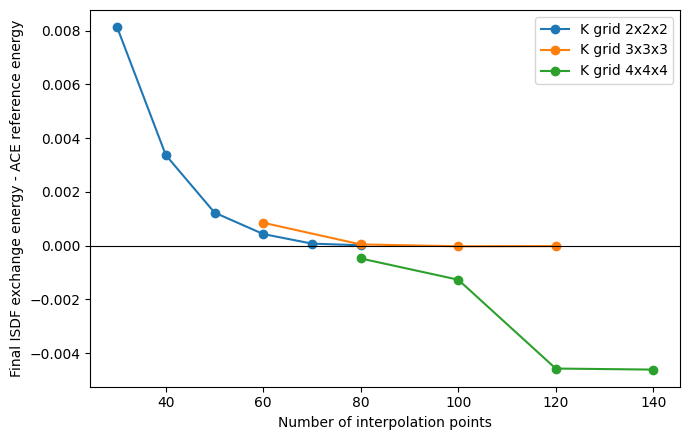

In [13]:
""" This is how codex suggested plotting with pandas. I find this to be an unintuitive mess to set up
"""
import pandas as pd
import matplotlib.pyplot as plt

from periodic_isdf_results import ResultsDB

db = ResultsDB()

with db.connect() as con:
    df = pd.read_sql_query(
        """
        SELECT
            r.cluster_id,
            r.remote_path,
            r.json_filename,
            r.updated_at,
            i.isdf_npoints,
            i.kpoints_grid,
            e.scf_step,
            e.exchange_energy
        FROM runs r
        JOIN run_inputs i ON i.run_id = r.run_id
        JOIN exchange_energy e ON e.run_id = r.run_id
        """,
        con,
    )

# Keep only the final SCF energy from each calculation.
final = (
    df.sort_values("scf_step")
      .groupby(["cluster_id", "remote_path", "json_filename"], as_index=False)
      .tail(1)
      .copy()
)

def kgrid_label(value):
    if pd.isna(value):
        return "unknown"
    grid = json.loads(value)
    return "x".join(str(x) for x in grid)

final["kgrid"] = final["kpoints_grid"].map(kgrid_label)

# ACE references are the calculations with no ISDFNpoints.
ace = final[final["isdf_npoints"].isna()].copy()
isdf = final[final["isdf_npoints"].notna()].copy()

ace_by_kgrid = ace[["kgrid", "exchange_energy"]].rename(
    columns={"exchange_energy": "ace_exchange_energy"}
)

plot_df = isdf.merge(ace_by_kgrid, on="kgrid", how="left")
plot_df["energy_minus_ace"] = plot_df["exchange_energy"] - plot_df["ace_exchange_energy"]
plot_df["isdf_npoints"] = plot_df["isdf_npoints"].astype(int)

print(
    plot_df[
        ["kgrid", "isdf_npoints", "energy_minus_ace", "exchange_energy", "ace_exchange_energy", "remote_path"]
    ].sort_values(["kgrid", "isdf_npoints"]).to_string(index=False)
)

fig, ax = plt.subplots(figsize=(7, 4.5))

for kgrid, group in plot_df.groupby("kgrid"):
    group = group.sort_values("isdf_npoints")
    ax.plot(
        group["isdf_npoints"],
        group["energy_minus_ace"],
        marker="o",
        linestyle="-",
        label=f"K grid {kgrid}",
    )

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Number of interpolation points")
ax.set_ylabel("Final ISDF exchange energy - ACE reference energy")
ax.legend()
fig.tight_layout()
plt.show()




In [15]:
""" Put the same results into a dict
"""
import json
from periodic_isdf_results import ResultsDB

db = ResultsDB()

results = {}

with db.connect() as con:
    rows = con.execute(
        """
        SELECT cluster_id, remote_path, json_filename, raw_json
        FROM runs
        ORDER BY remote_path
        """
    ).fetchall()

for row in rows:
    key = row["remote_path"]
    results[key] = json.loads(row["raw_json"])

results.keys()

dict_keys(['/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid111_ACE', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ACE', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints30', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints40', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints50', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints60', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints70', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid222_ISDFNpoints80', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid333_ACE', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid333_ISDFNpoints100', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid333_ISDFNpoints120', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid333_ISDFNpoints60', '/home/bucchera/periodic_isdf/silicon_qindp/KPointsGrid333_ISDFNpoints80', '/home/bucchera/periodic_isdf/silicon_qind

(2, 2, 2): [4.06406252e-03 1.68354519e-03 6.14195778e-04 2.15420511e-04
 3.77545412e-05 6.62368497e-06]
(3, 3, 3): [ 4.25548053e-04  2.28744572e-05 -1.18044913e-05 -8.32088097e-06]


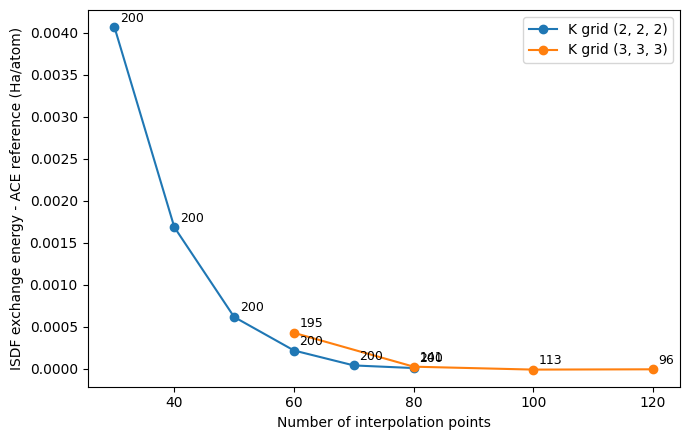

(4, 4, 4): [-0.0002385  -0.00063369 -0.00228548 -0.00230515]


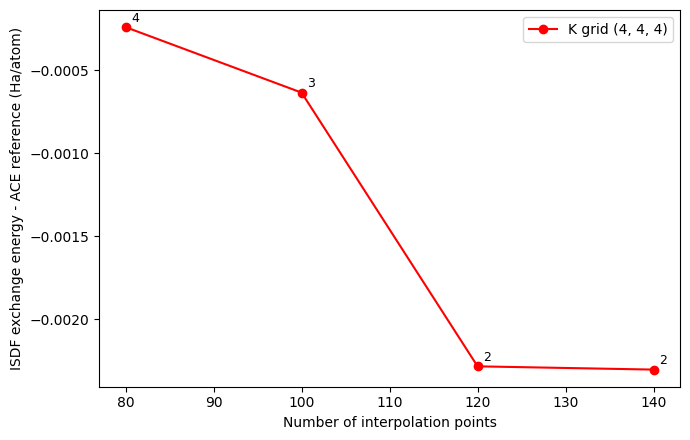

In [46]:
""" Final Exact Exchange Energy w.r.t Number of ISDF Vectors
"""
import numpy as np
import matplotlib.pyplot as plt

base = "/home/bucchera/periodic_isdf/silicon_qindp"


# (1, 1, 1)
# These ISDF calcs failed - need to rerun

kgrid_to_keys = {
    (2, 2, 2): ["ISDFNpoints30", "ISDFNpoints40", "ISDFNpoints50", "ISDFNpoints60", "ISDFNpoints70", "ISDFNpoints80"],
    (3, 3, 3): ["ISDFNpoints60", "ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120"],
}

fig, ax = plt.subplots(figsize=(7, 4.5))

for kgrid, keys in kgrid_to_keys.items():
    kgrid_str = "".join(str(x) for x in kgrid)
    root_key = f"{base}/KPointsGrid{kgrid_str}"

    ace_ex = results[root_key + "_ACE"]["exchange_energy"]["exchange_energy"][-1]
    nisdf = []
    exx = []
    nscf = []

    for key in keys:
        full_key = root_key + "_" + key

        if full_key not in results:
            print(f"Missing: {full_key}")
            continue

        nisdf.append(results[full_key]["inp"]["ISDFNpoints"])
        exx.append(results[full_key]["exchange_energy"]["exchange_energy"][-1])
        nscf.append(results[full_key]["exchange_energy"]["scf_step"][-1])

    energy = 0.5 * (np.array(exx) - ace_ex)
    ax.plot(
        nisdf,
        energy,
        marker="o",
        linestyle="-",
        label=f"K grid {kgrid}",
    )
    for x_i, y_i, n_i in zip(nisdf, energy, nscf):
     ax.annotate(
         str(n_i),
         xy=(x_i, y_i),
         xytext=(4, 4),
         textcoords="offset points",
         fontsize=9,
     )
    print(f"{kgrid}: {0.5 * (np.array(exx) - ace_ex)}")

ax.set_xlabel("Number of interpolation points")
ax.set_ylabel("ISDF exchange energy - ACE reference (Ha/atom)")
ax.legend()
fig.tight_layout()
plt.show()


# Plot  (4, 4, 4) separately because the results look erroneous
kgrid = (4, 4, 4)
kgrid_str = "".join(str(x) for x in kgrid)
root_key = f"{base}/KPointsGrid444"
keys = ["ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120", "ISDFNpoints140"]

ace_ex = results[root_key + "_ACE"]["exchange_energy"]["exchange_energy"][-1]
nisdf = []
exx = []
nscf = []
for key in keys:
    full_key = root_key + "_" + key

    if full_key not in results:
        print(f"Missing: {full_key}")
        continue

    nisdf.append(results[full_key]["inp"]["ISDFNpoints"])
    exx.append(results[full_key]["exchange_energy"]["exchange_energy"][-1])
    nscf.append(results[full_key]["exchange_energy"]["scf_step"][-1])

fig, ax = plt.subplots(figsize=(7, 4.5))

energy = 0.5 * (np.array(exx) - ace_ex)
ax.plot(
    nisdf,
    energy,
    marker="o",
    color='red',
    linestyle="-",
    label=f"K grid {kgrid}",
)

for x_i, y_i, n_i in zip(nisdf, energy, nscf):
     ax.annotate(
         str(n_i),
         xy=(x_i, y_i),
         xytext=(4, 4),
         textcoords="offset points",
         fontsize=9,
     )

print(f"{kgrid}: {0.5 * (np.array(exx) - ace_ex)}")

ax.set_xlabel("Number of interpolation points")
ax.set_ylabel("ISDF exchange energy - ACE reference (Ha/atom)")
ax.legend()
fig.tight_layout()
plt.show()


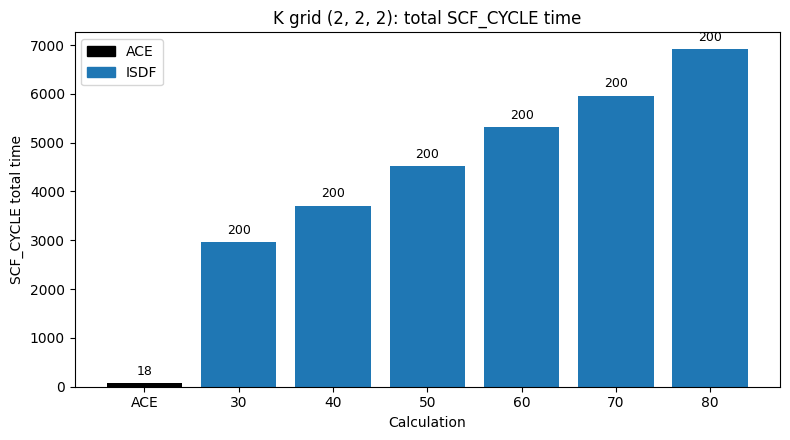

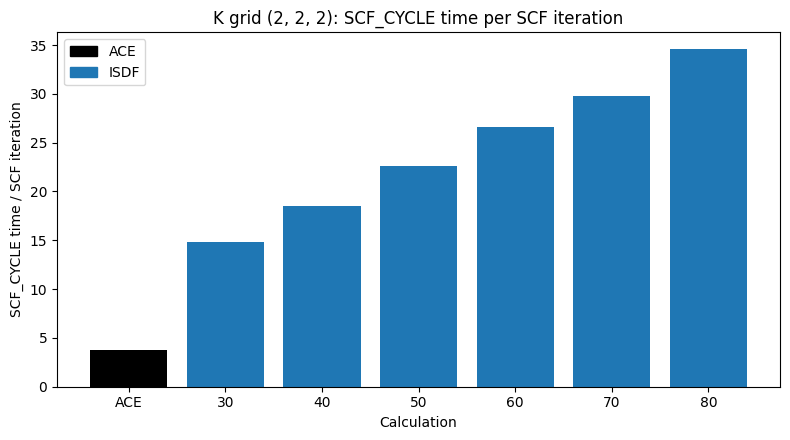

nscf: [ 18 200 200 200 200 200 200]
total times: [  68.118634 2958.906001 3703.088324 4520.355845 5317.315065 5957.60284
 6914.291667]
time per SCF: [ 3.78436856 14.79453    18.51544162 22.60177923 26.58657532 29.7880142
 34.57145834]


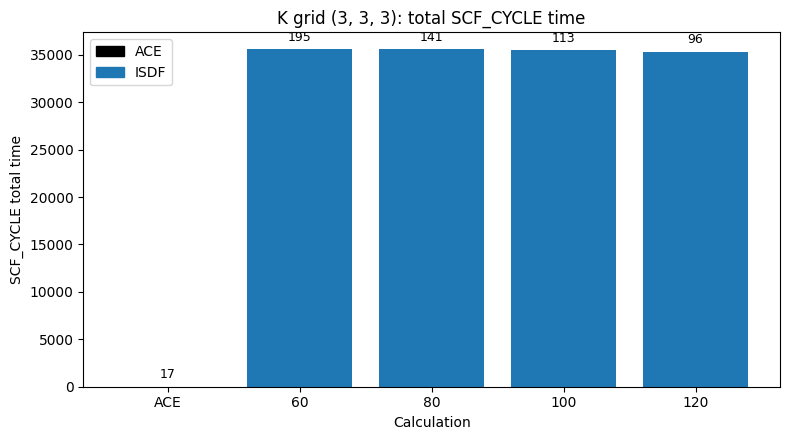

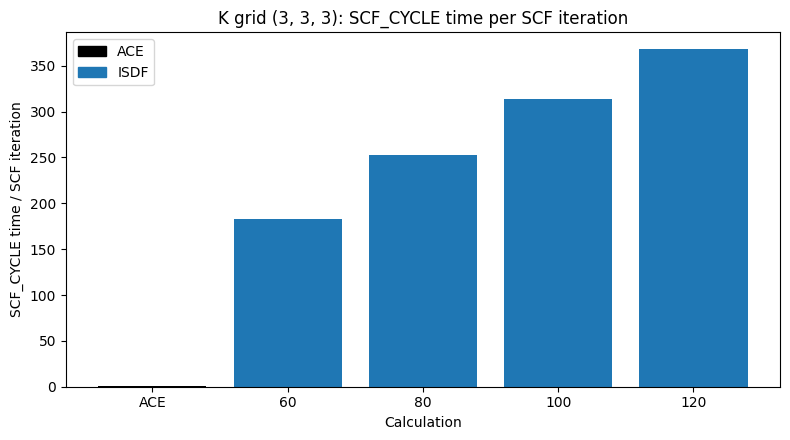

nscf: [ 17 195 141 113  96]
total times: [2.19986540e+01 3.55866588e+04 3.55714310e+04 3.54817595e+04
 3.53375219e+04]
time per SCF: [  1.29403847 182.49568605 252.27965264 313.99787204 368.09918629]


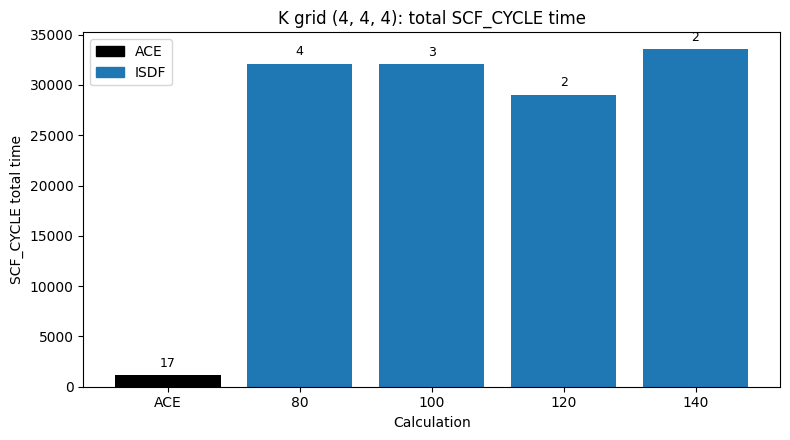

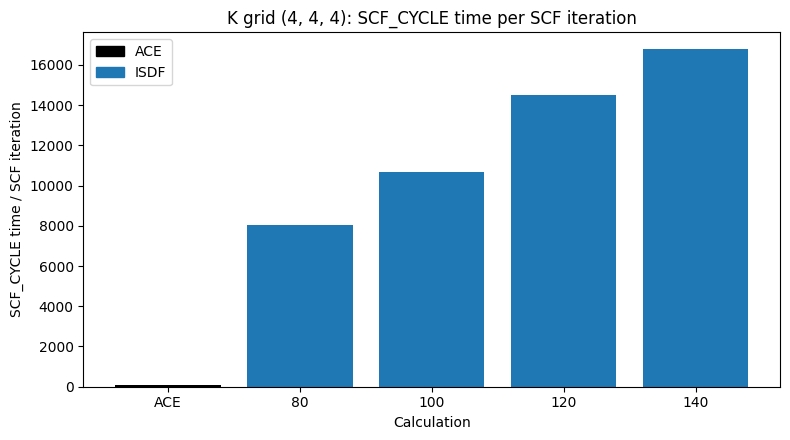

nscf: [17  4  3  2  2]
total times: [ 1118.776733 32102.969001 32074.831971 29003.318854 33553.668212]
time per SCF: [   65.81039606  8025.74225025 10691.610657   14501.659427
 16776.834106  ]


In [51]:
""" Timing Comparisons - Total Time
"""
""" SCF_CYCLE profiling time histogram: ACE vs ISDF
"""
""" SCF_CYCLE profiling time histograms: ACE vs ISDF
    Also plots SCF_CYCLE time normalised by number of SCF iterations.
"""
import numpy as np
import matplotlib.pyplot as plt

base = "/home/bucchera/periodic_isdf/silicon_qindp"

kgrid_to_keys = {
    (2, 2, 2): ["ISDFNpoints30", "ISDFNpoints40", "ISDFNpoints50", "ISDFNpoints60", "ISDFNpoints70", "ISDFNpoints80"],
    (3, 3, 3): ["ISDFNpoints60", "ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120"],
    (4, 4, 4): ["ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120", "ISDFNpoints140"],
}

profile_key = "cumulative_times"   # or "self_times"
routine = "SCF_CYCLE"
field = "TOTAL_TIME"

def scf_cycle_time(result):
    return result[profile_key][routine][field]

def final_nscf(result):
    return result["exchange_energy"]["scf_step"][-1]

def plot_bars(labels, values, nscf, colors, ylabel, title, annotate_nscf=True):
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(x, values, color=colors)

    if annotate_nscf:
        for bar, n_i in zip(bars, nscf):
            ax.annotate(
                str(n_i),
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_title(title)
    ax.set_xlabel("Calculation")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    ax.legend(handles=[
        plt.Rectangle((0, 0), 1, 1, color="black", label="ACE"),
        plt.Rectangle((0, 0), 1, 1, color="tab:blue", label="ISDF"),
    ])

    fig.tight_layout()
    plt.show()

for kgrid, keys in kgrid_to_keys.items():
    kgrid_str = "".join(str(x) for x in kgrid)
    root_key = f"{base}/KPointsGrid{kgrid_str}"

    ace_key = root_key + "_ACE"
    ace_time = scf_cycle_time(results[ace_key])
    ace_nscf = final_nscf(results[ace_key])

    labels = ["ACE"]
    times = [ace_time]
    nscf = [ace_nscf]
    colors = ["black"]

    for key in keys:
        full_key = root_key + "_" + key

        if full_key not in results:
            print(f"Missing: {full_key}")
            continue

        labels.append(str(results[full_key]["inp"]["ISDFNpoints"]))
        times.append(scf_cycle_time(results[full_key]))
        nscf.append(final_nscf(results[full_key]))
        colors.append("tab:blue")

    times = np.array(times, dtype=float)
    nscf = np.array(nscf, dtype=float)
    times_per_scf = times / nscf

    plot_bars(
        labels,
        times,
        nscf.astype(int),
        colors,
        ylabel="SCF_CYCLE total time",
        title=f"K grid {kgrid}: total SCF_CYCLE time",
        annotate_nscf=True,
    )

    plot_bars(
        labels,
        times_per_scf,
        nscf.astype(int),
        colors,
        ylabel="SCF_CYCLE time / SCF iteration",
        title=f"K grid {kgrid}: SCF_CYCLE time per SCF iteration",
        annotate_nscf=False,
    )

    print("nscf:", nscf.astype(int))
    print("total times:", times)
    print("time per SCF:", times_per_scf)

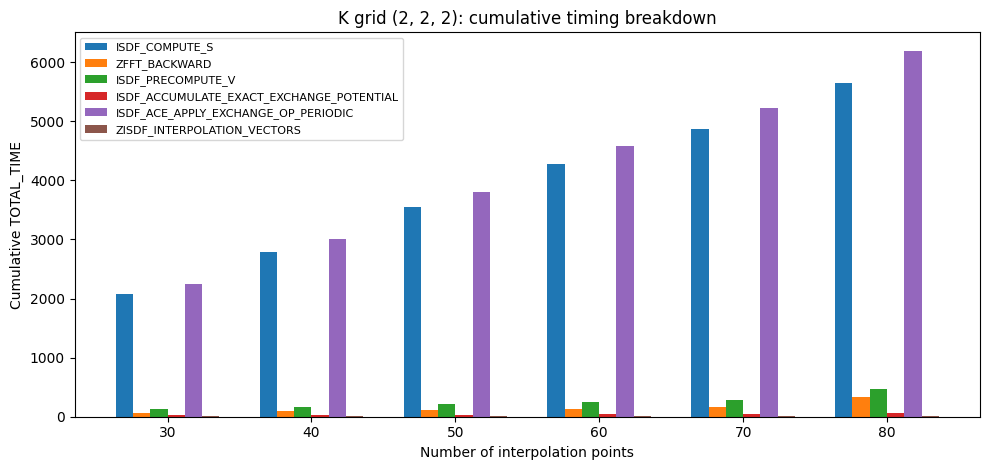

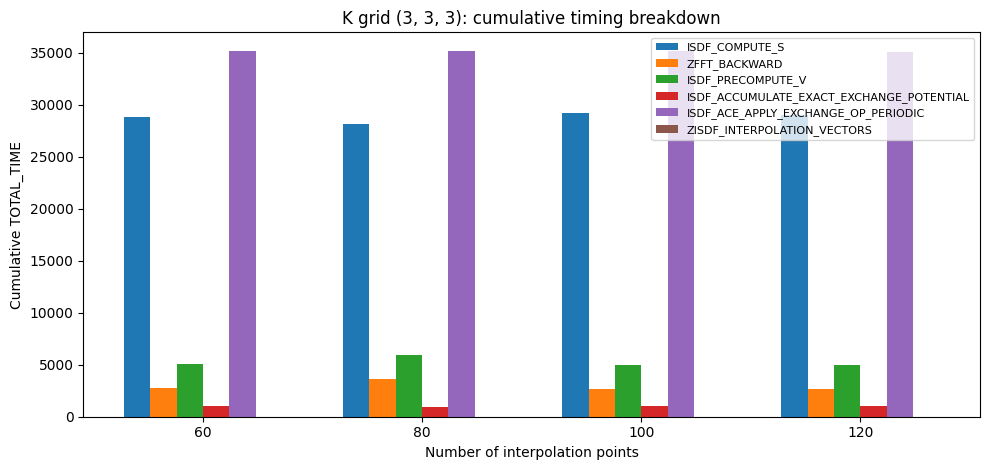

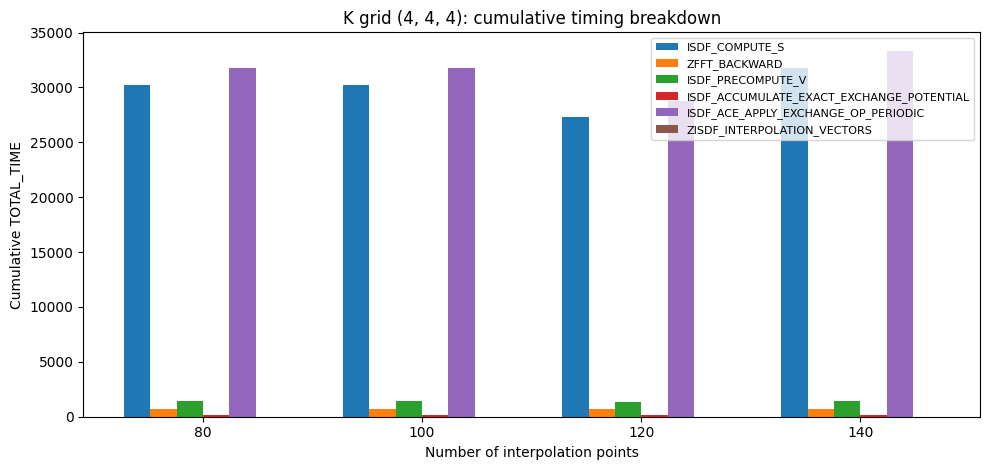

In [52]:
""" Cumulative timing breakdown per ISDFNpoints, one plot per k-grid.
"""
import numpy as np
import matplotlib.pyplot as plt

base = "/home/bucchera/periodic_isdf/silicon_qindp"

kgrid_to_keys = {
    (2, 2, 2): ["ISDFNpoints30", "ISDFNpoints40", "ISDFNpoints50", "ISDFNpoints60", "ISDFNpoints70", "ISDFNpoints80"],
    (3, 3, 3): ["ISDFNpoints60", "ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120"],
    (4, 4, 4): ["ISDFNpoints80", "ISDFNpoints100", "ISDFNpoints120", "ISDFNpoints140"],
}

routines = [
    "ISDF_COMPUTE_S",
    "ZFFT_BACKWARD",
    "ISDF_PRECOMPUTE_V",
    "ISDF_ACCUMULATE_EXACT_EXCHANGE_POTENTIAL",
    "ISDF_ACE_APPLY_EXCHANGE_OP_PERIODIC",
    "ZISDF_INTERPOLATION_VECTORS",
]

profile_key = "cumulative_times"
field = "TOTAL_TIME"

for kgrid, keys in kgrid_to_keys.items():
    kgrid_str = "".join(str(x) for x in kgrid)
    root_key = f"{base}/KPointsGrid{kgrid_str}"

    nisdf = []
    routine_times = {routine: [] for routine in routines}

    for key in keys:
        full_key = root_key + "_" + key

        if full_key not in results:
            print(f"Missing: {full_key}")
            continue

        result = results[full_key]
        nisdf.append(result["inp"]["ISDFNpoints"])

        for routine in routines:
            value = result[profile_key].get(routine, {}).get(field, 0.0)
            routine_times[routine].append(value)

    x = np.arange(len(nisdf))
    width = 0.12

    fig, ax = plt.subplots(figsize=(10, 4.8))

    for i, routine in enumerate(routines):
        offset = (i - (len(routines) - 1) / 2) * width
        ax.bar(
            x + offset,
            routine_times[routine],
            width=width,
            label=routine,
        )

    ax.set_title(f"K grid {kgrid}: cumulative timing breakdown")
    ax.set_xlabel("Number of interpolation points")
    ax.set_ylabel("Cumulative TOTAL_TIME")
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in nisdf])
    ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()